# 05 — MCMC Fitting a Grating Spectrum

This notebook demonstrates MCMC fitting on a G395M grating spectrum
where individual lines are resolved.  It covers:
1. MCMC fit of a grating spectrum with resolved [NII]–Hα–[NII]
2. Convergence diagnostics (R-hat, ESS)
3. Corner plots of correlated parameters (e.g. [NII]/Hα)
4. Flux-ratio posteriors: O3/Hβ and N2/Hα for BPT diagnostics
5. Nautilus nested sampler as an alternative to emcee
6. Compare MLE, bootstrap, and MCMC uncertainties
7. BIC-based broad Balmer component selection with MCMC posteriors

In [1]:
import jwspecfit
import jwspecmcmc
import matplotlib.pyplot as plt
import numpy as np

print(f"jwspecfit  v{jwspecfit.__version__}")
print(f"jwspecmcmc v{jwspecmcmc.__version__}")

jwspecfit  v0.1.0
jwspecmcmc v0.1.0


## Load the G395M spectrum

Same grating spectrum as notebook 02.  The G395M has R ≈ 1000,
resolving [NII] from Hα and the [SII] doublet.

In [2]:
spec = jwspecfit.read_fits(
    "../../data/stark-rxcj2248-v4_g395m-f290lp_2478_3.spec.fits",
    z=6.1052,
)

print(f"Grating:    {spec.grating}")
print(f"Pixels:     {spec.n_pix}")
print(f"Wave range: {spec.wave_um.min():.3f} \u2013 {spec.wave_um.max():.3f} \u00b5m")

Grating:    G395M
Pixels:     1661
Wave range: 2.680 – 5.510 µm


## Quick look at the raw spectrum

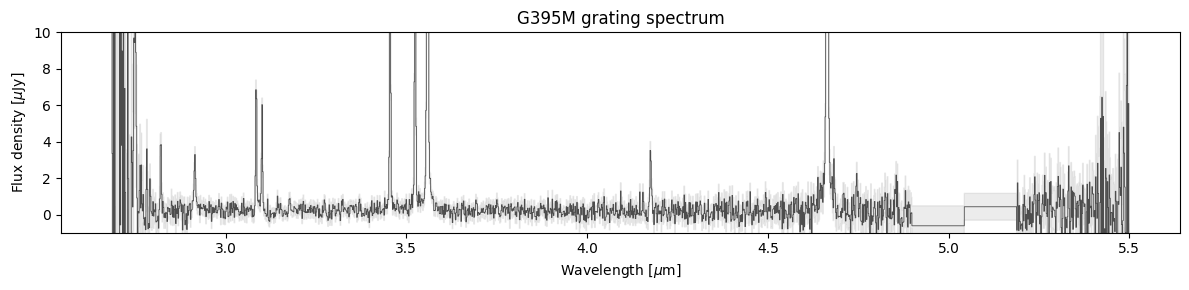

In [4]:
fig, ax = plt.subplots(figsize=(12, 3))
valid = spec.mask_valid()
ax.step(spec.wave_um[valid], spec.flux_ujy[valid], where="mid", lw=0.6, color="0.3")
ax.fill_between(
    spec.wave_um[valid],
    (spec.flux_ujy - spec.err_ujy)[valid],
    (spec.flux_ujy + spec.err_ujy)[valid],
    step="mid", alpha=0.15, color="0.5",
)
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylim(-1,10)
ax.set_ylabel(r"Flux density [$\mu$Jy]")
ax.set_title("G395M grating spectrum")
plt.tight_layout()

## MCMC fit with emcee

Fit all observable lines using emcee.  The grating resolves many more
lines than the prism, so the parameter space is larger.

In [5]:
result = jwspecmcmc.fit_lines(
    spec, z=6.1052,
    sampler="emcee",
    n_steps=3000,
    n_walkers=128,
    deg=3,
    seed=42,
)

print(f"Sampler:     {result.sampler_name}")
print(f"Lines:       {len(result.lines)} fitted")
print(f"Chain shape: {result.flat_chains.shape}")
print(f"Burn-in:     {result.sampler_meta.get('n_burn', '?')} steps")

100%|██████████| 3000/3000 [02:28<00:00, 20.21it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 25 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [184.19514307  92.01840646 109.50924829  65.30966506  42.39988423
  27.59106496 212.33363929 183.86428342  32.85125809 264.95751322
 267.56427156 244.62089875 233.77822232 231.7625843  237.26358265
 271.00689651 244.66214415 299.17645027 298.84372615 364.72638343
 243.82445891 228.60477864 232.03394201 357.70365289 280.90942016
 329.41746122 335.6454804  353.89312027]


Sampler:     emcee
Lines:       13 fitted
Chain shape: (290688, 39)
Burn-in:     729 steps


## Per-line results

Asymmetric 68% credible intervals from the posterior.

In [6]:
print(f"{'Line':<18s} {'Flux':>12s} {'\u2212err':>12s} {'+err':>12s} {'SNR':>8s} {'EW (\u00c5)':>10s}")
print("-" * 76)
for name, lr in result.lines.items():
    print(
        f"{name:<18s} {lr.flux:12.3e} {lr.flux_err[0]:12.3e} {lr.flux_err[1]:12.3e}"
        f" {lr.snr:8.1f} {lr.ew_A:10.1f}"
    )

Line                       Flux         −err         +err      SNR     EW (Å)
----------------------------------------------------------------------------
HDELTA                3.813e-18    4.751e-19    4.367e-19      8.4       69.9
HGAMMA                7.936e-18    4.623e-19    4.711e-19     17.0      146.4
OIII_4363             6.137e-18    4.117e-19    4.390e-19     14.4      113.6
HBETA                 1.719e-17    4.734e-19    4.890e-19     35.7      378.5
OIII_4959             2.997e-17    5.524e-19    6.050e-19     51.8      693.0
OIII_5007             8.788e-17    9.577e-19    9.256e-19     93.3     2085.5
NII_5756              4.023e-19    1.984e-19    2.015e-19      2.0       15.8
HEI_5877              2.840e-18    3.445e-19    3.359e-19      8.3      121.5
NII_6549              1.335e-18    1.780e-19    1.770e-19      7.5       88.6
Ha                    4.210e-17    6.555e-19    6.647e-19     63.8     2816.6
NII_6585              3.951e-18    5.268e-19    5.240e-19      7.

## Convergence diagnostics

Check that the chains have converged: R-hat < 1.05 and ESS > 100.

In [7]:
conv = result.convergence
print(f"R-hat max:  {conv.get('r_hat_max', 'N/A'):.4f}")
print(f"ESS min:    {conv.get('ess_min', 'N/A'):.0f}")
print(f"Converged:  {conv.get('converged', 'N/A')}")

if 'r_hat' in conv:
    r_hat = conv['r_hat']
    print(f"\nR-hat range: {np.nanmin(r_hat):.4f} \u2013 {np.nanmax(r_hat):.4f}")
    n_bad = np.sum(r_hat > 1.05)
    if n_bad > 0:
        print(f"WARNING: {n_bad} parameters have R-hat > 1.05")

R-hat max:  1.3255
ESS min:    602
Converged:  False

R-hat range: 1.1289 – 1.3255


## Trace plots

Visualise chain mixing for key parameters.

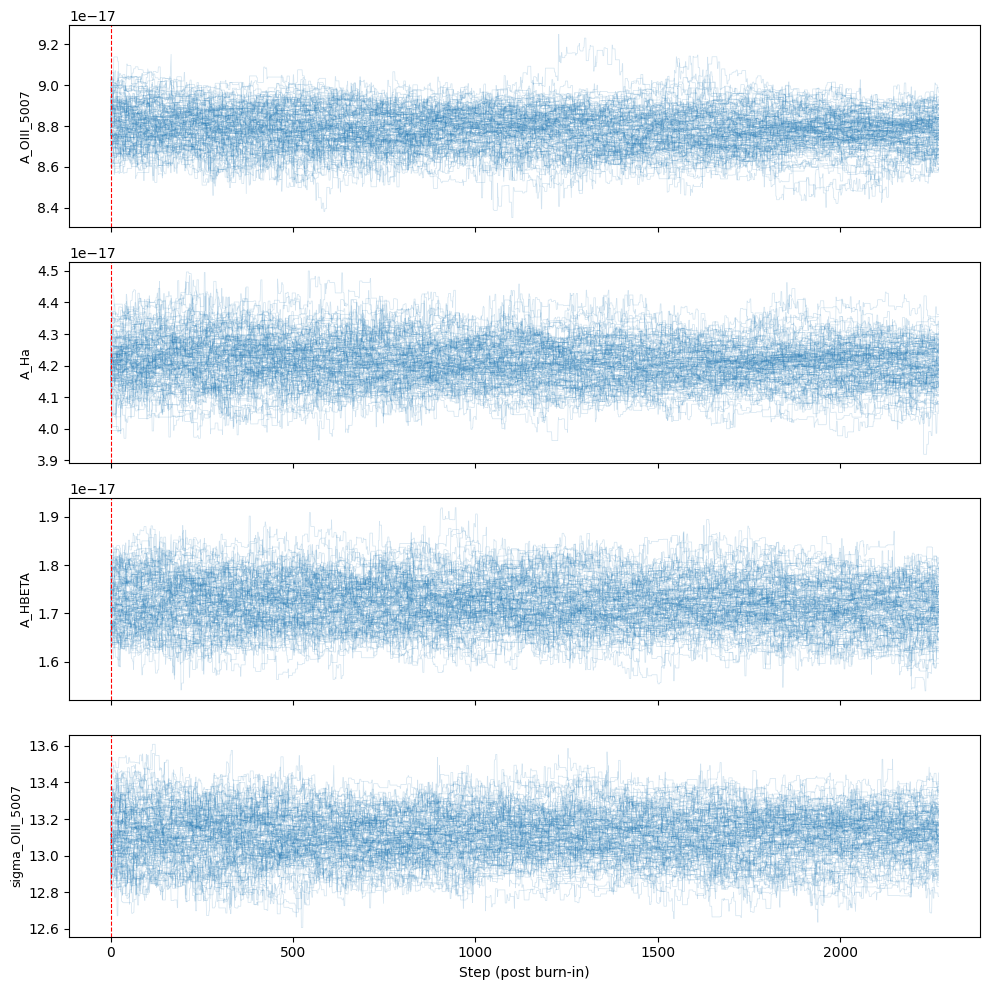

In [8]:
fig = jwspecmcmc.plot_traces(
    result,
    params=["A_OIII_5007", "A_Ha", "A_HBETA", "sigma_OIII_5007"],
)
plt.show()

## Flux posterior histograms

Posterior distributions for the brightest lines.

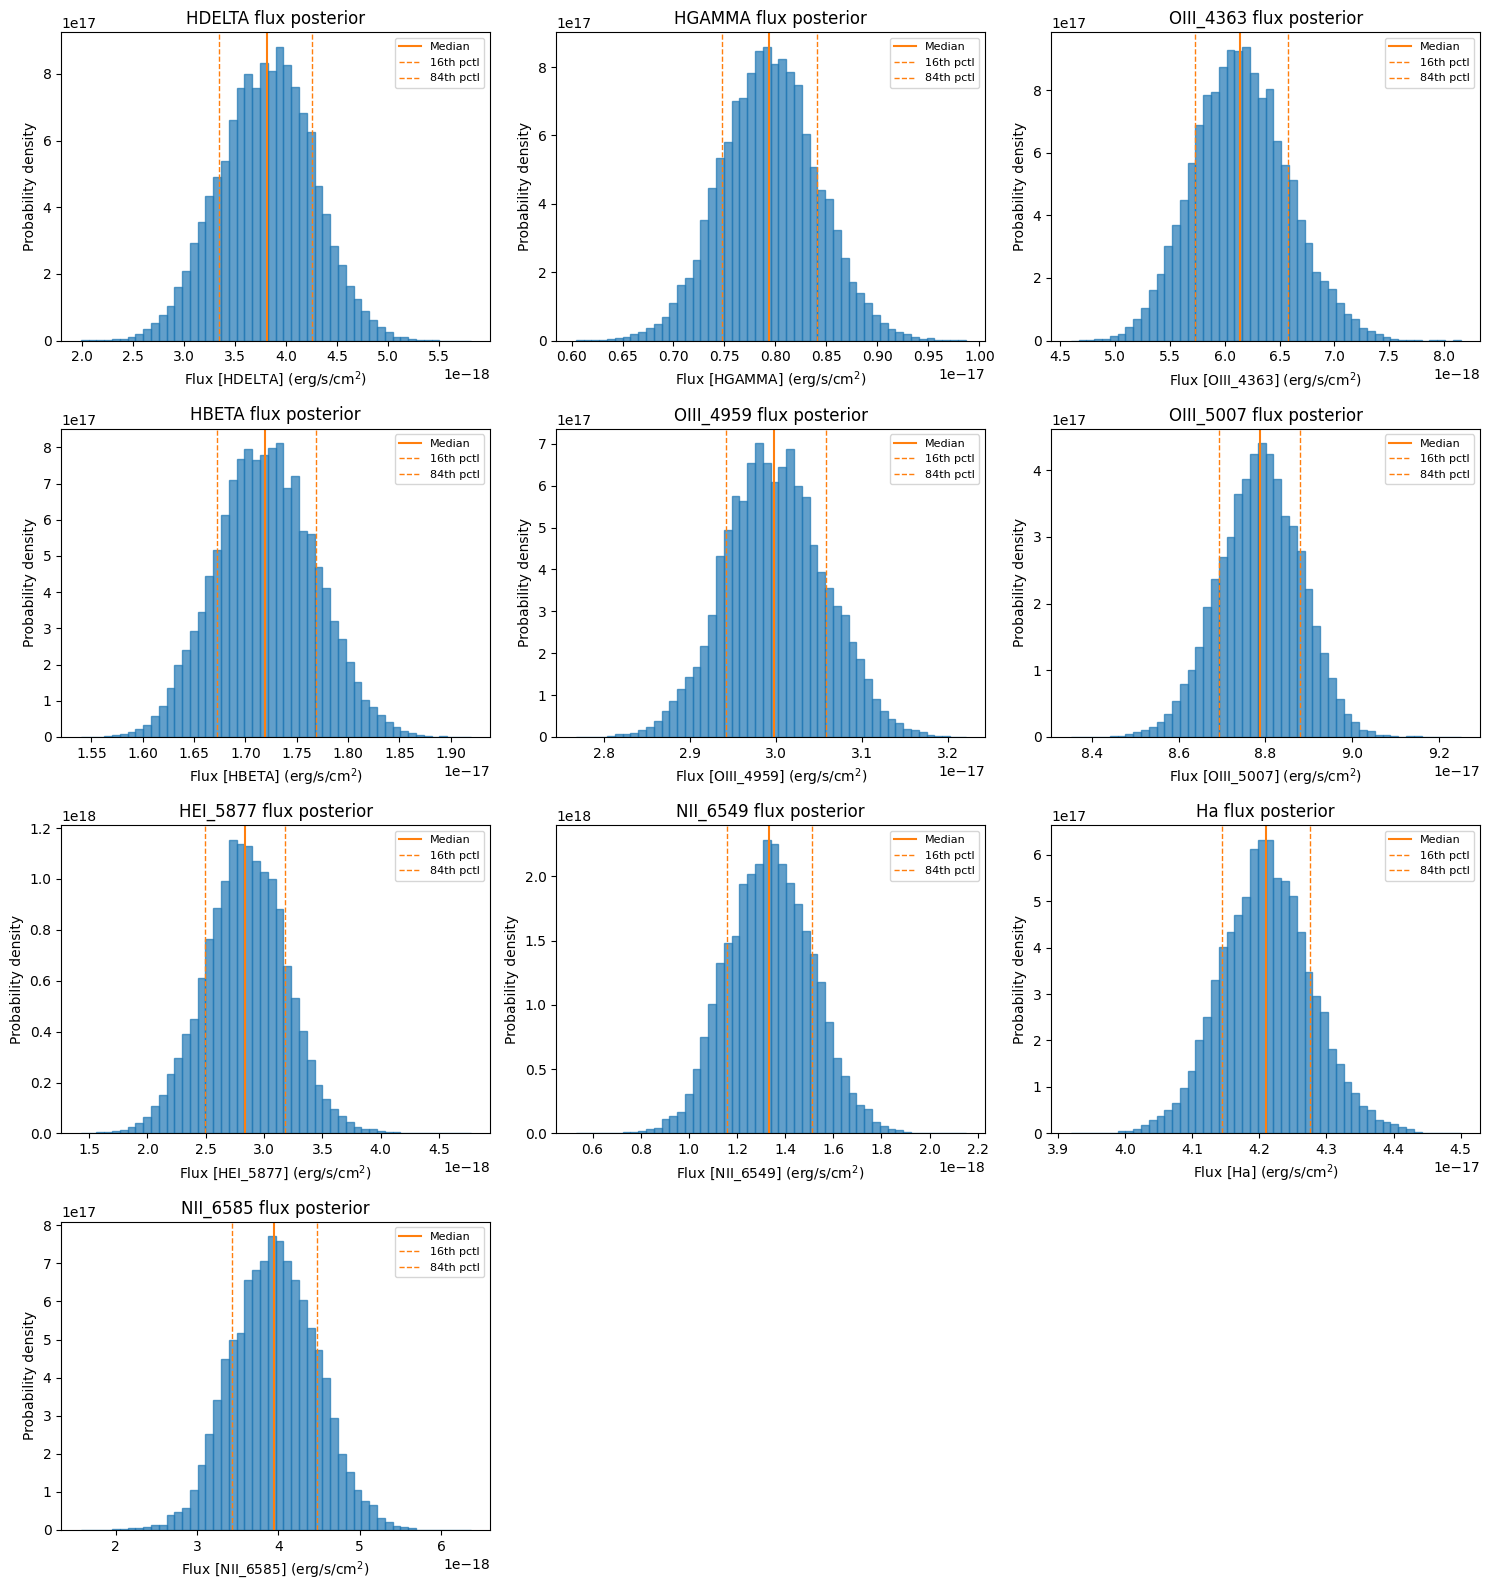

In [9]:
bright_lines = [name for name, lr in result.lines.items() if lr.snr > 5]
n_bright = len(bright_lines)

if n_bright > 0:
    ncols = min(n_bright, 3)
    nrows = (n_bright + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, line in zip(axes, bright_lines):
        jwspecmcmc.plot_flux_posterior(result, line, ax=ax)
    for ax in axes[n_bright:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No lines with SNR > 5.")

## Corner plot: Hα + [NII] complex

Joint posterior of Hα and [NII] 6585 amplitudes and the OIII sigma.

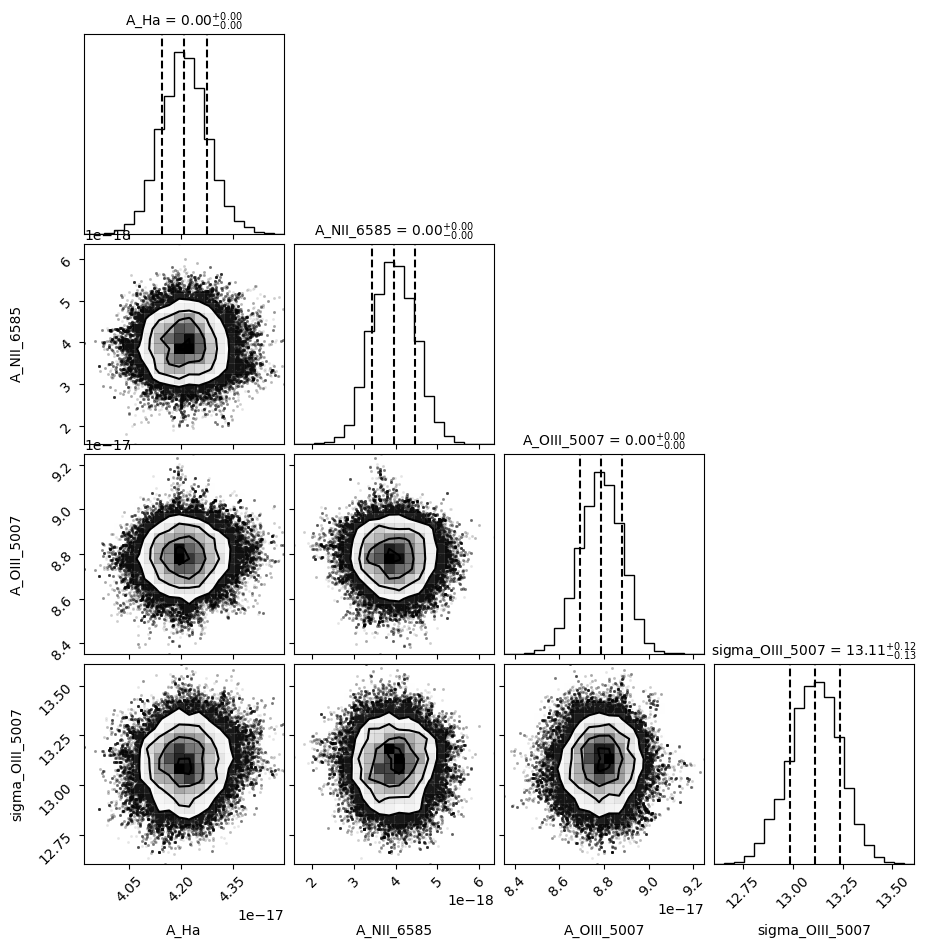

In [10]:
corner_params = ["A_Ha", "A_NII_6585", "A_OIII_5007", "sigma_OIII_5007"]
# Only include params that are in the result
corner_params = [p for p in corner_params if p.split("_", 1)[1] in result.lines or
                 p.replace("sigma_", "") in result.lines or
                 p.replace("mu_", "") in result.lines]

if len(corner_params) >= 2:
    fig = jwspecmcmc.plot_corner(result, params=corner_params)
    plt.show()

## Flux-ratio posteriors for BPT diagnostics

Compute the posteriors on log([OIII] 5007 / Hβ) and
log([NII] 6585 / Hα) — the standard BPT axes.

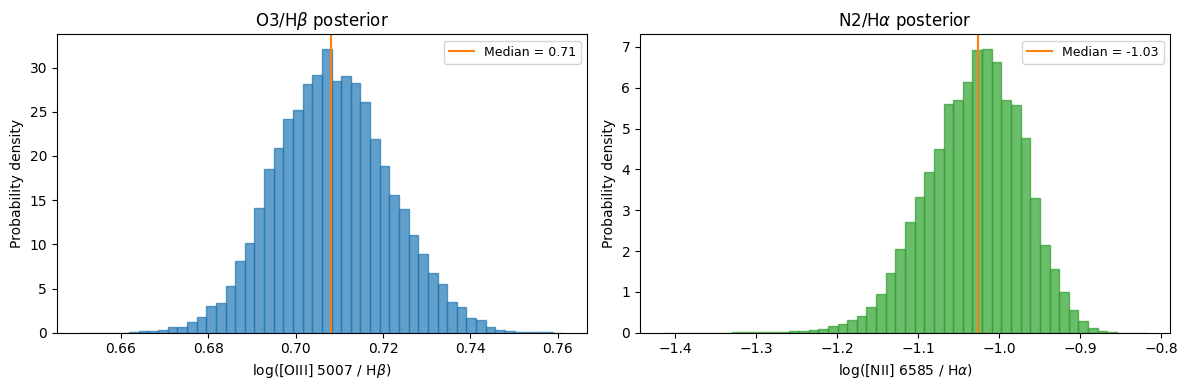

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# O3/Hbeta
if "OIII_5007" in result.lines and "HBETA" in result.lines:
    ratio_o3hb = result.flux_ratio_posterior("OIII_5007", "HBETA")
    ratio_o3hb = ratio_o3hb[np.isfinite(ratio_o3hb) & (ratio_o3hb > 0)]
    if len(ratio_o3hb) > 0:
        log_o3hb = np.log10(ratio_o3hb)
        axes[0].hist(log_o3hb, bins=50, density=True, alpha=0.7, color="C0", edgecolor="C0")
        med = np.median(log_o3hb)
        axes[0].axvline(med, color="C1", ls="-", lw=1.5, label=f"Median = {med:.2f}")
        axes[0].set_xlabel(r"log([OIII] 5007 / H$\beta$)")
        axes[0].set_ylabel("Probability density")
        axes[0].legend(fontsize=9)
        axes[0].set_title(r"O3/H$\beta$ posterior")

# N2/Halpha
if "NII_6585" in result.lines and "Ha" in result.lines:
    ratio_n2ha = result.flux_ratio_posterior("NII_6585", "Ha")
    ratio_n2ha = ratio_n2ha[np.isfinite(ratio_n2ha) & (ratio_n2ha > 0)]
    if len(ratio_n2ha) > 0:
        log_n2ha = np.log10(ratio_n2ha)
        axes[1].hist(log_n2ha, bins=50, density=True, alpha=0.7, color="C2", edgecolor="C2")
        med = np.median(log_n2ha)
        axes[1].axvline(med, color="C1", ls="-", lw=1.5, label=f"Median = {med:.2f}")
        axes[1].set_xlabel(r"log([NII] 6585 / H$\alpha$)")
        axes[1].set_ylabel("Probability density")
        axes[1].legend(fontsize=9)
        axes[1].set_title(r"N2/H$\alpha$ posterior")

plt.tight_layout()
plt.show()

## Plot the MCMC fit

Convert to `FitResult` and use `plot_fit()` for the standard
data + model + residuals view.

χ²/dof = 1.18


/Users/raunaqrai/miniforge3/envs/jwst/lib/python3.12/site-packages/jwspecfit/plotting.py:284: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


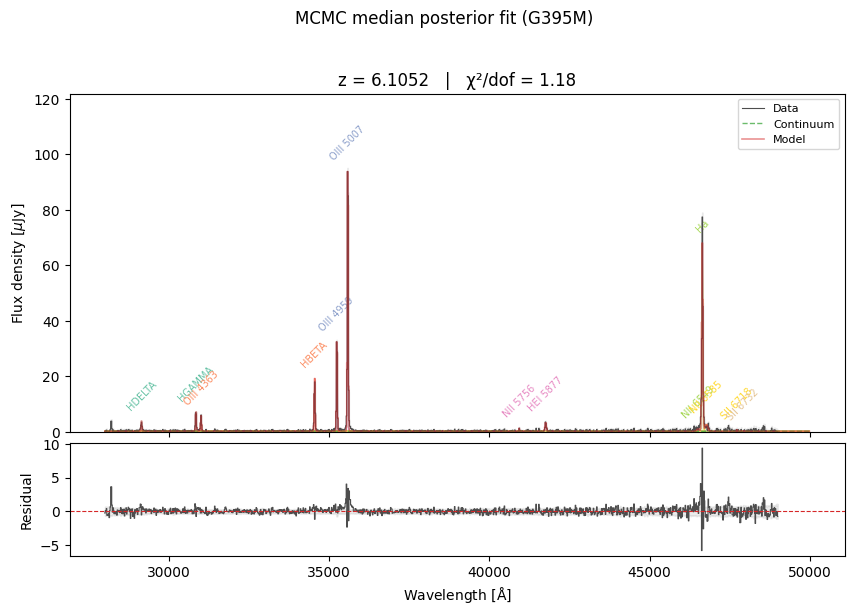

In [12]:
fit_result = result.to_fit_result()
print(f"\u03c7\u00b2/dof = {fit_result.chi2:.2f}")

fig = jwspecfit.plot_fit(fit_result, exclude_wave_A=[(20000, 28000), (50000, 60000)])
fig.suptitle("MCMC median posterior fit (G395M)", y=1.02)
plt.show()

In [13]:
fig_interactive = jwspecfit.plot_fit_interactive(fit_result)
fig_interactive.show()

## Compare MLE and MCMC uncertainties

Run the standard bootstrap fit and compare error bars.

In [14]:
result_lsq = jwspecfit.fit_lines(spec, z=6.1052, deg=3, n_boot=1000)

print(f"{'Line':<18s} {'Flux':>12s} {'Boot err':>12s} {'MCMC \u2212err':>12s} {'MCMC +err':>12s}")
print("-" * 70)
for name in result_lsq.lines:
    if name in result.lines:
        lr_lsq = result_lsq.lines[name]
        lr_mc = result.lines[name]
        print(
            f"{name:<18s} {lr_lsq.flux:12.3e} {lr_lsq.flux_err:12.3e}"
            f" {lr_mc.flux_err[0]:12.3e} {lr_mc.flux_err[1]:12.3e}"
        )

Bootstrap: 100%|██████████| 1000/1000 [00:29<00:00, 34.41iter/s]

Line                       Flux     Boot err    MCMC −err    MCMC +err
----------------------------------------------------------------------
HDELTA                3.752e-18    4.729e-19    4.751e-19    4.367e-19
HGAMMA                7.943e-18    6.259e-19    4.623e-19    4.711e-19
OIII_4363             6.082e-18    1.042e-18    4.117e-19    4.390e-19
HBETA                 1.720e-17    8.776e-19    4.734e-19    4.890e-19
OIII_4959             2.999e-17    1.175e-18    5.524e-19    6.050e-19
OIII_5007             8.796e-17    1.139e-18    9.577e-19    9.256e-19
NII_5756              3.827e-19    2.575e-19    1.984e-19    2.015e-19
HEI_5877              2.828e-18    4.609e-19    3.445e-19    3.359e-19
NII_6549              1.355e-18    1.581e-19    1.780e-19    1.770e-19
Ha                    4.211e-17    1.526e-18    6.555e-19    6.647e-19
NII_6585              4.011e-18    4.681e-19    5.268e-19    5.240e-19
SII_6718              7.916e-20    3.026e-19    1.460e-19    2.300e-19
SII_67

## Nautilus nested sampler

As an alternative to emcee, you can use `nautilus` for nested sampling.
This automatically computes the Bayesian evidence and does not require
burn-in tuning.  Note: trace plots are not available for nautilus.

In [15]:
result_naut = jwspecmcmc.fit_lines(
    spec, z=6.1052,
    sampler="nautilus",
    lines=["OIII_4959", "OIII_5007", "HBETA", "Ha", "NII_6549", "NII_6585"],
    deg=3,
    n_live=1000,
    n_eff=5000,
)

print(f"Sampler: {result_naut.sampler_name}")
print(f"Samples: {result_naut.flat_chains.shape[0]}")
print()
for name, lr in result_naut.lines.items():
    print(f"  {name:<18s} flux={lr.flux:.3e} (-{lr.flux_err[0]:.3e}, +{lr.flux_err[1]:.3e})  SNR={lr.snr:.1f}")

TypeError: Sampler.run() got an unexpected keyword argument 'min_eff'

## Broad Balmer component selection with MCMC

`jwspecmcmc.fit_with_broad()` combines BIC-based model selection
(narrow vs broad Hα/Hβ) with full MCMC posterior sampling:

- **Phase 1**: Fast least-squares BIC comparison via `jwspecfit.fit_with_broad()`
- **Phase 2**: MCMC sampling on the winning model's line list

This avoids running expensive MCMC on all model variants — only the
BIC-selected model gets full posteriors.

In [ ]:
result_broad = jwspecmcmc.fit_with_broad(
    spec, z=6.1052,
    sampler="emcee",
    mode="auto",
    n_boot_bic=0,         # single-point BIC (fast; set >0 for bootstrap BIC)
    n_steps=3000,
    n_walkers=128,
    deg=3,
    seed=42,
)

print(f"Selected model: {result_broad.selected_model}")
print(f"BIC narrow:     {result_broad.bic_narrow:.1f}")
print(f"BIC broad1:     {result_broad.bic_broad1:.1f}")
print(f"BIC broad2:     {result_broad.bic_broad2:.1f}")
print(f"BIC both:       {result_broad.bic_both:.1f}")
print()
print(f"Lines fitted:   {result_broad.line_names}")
print(f"Chain shape:    {result_broad.flat_chains.shape}")

### Broad-fit per-line results

If broad components were selected, they appear alongside the narrow lines.

In [ ]:
print(f"{'Line':<22s} {'Flux':>12s} {'−err':>12s} {'+err':>12s} {'SNR':>8s}")
print("-" * 70)
for name, lr in result_broad.lines.items():
    tag = " *" if "BROAD" in name else ""
    print(
        f"{name + tag:<22s} {lr.flux:12.3e} {lr.flux_err[0]:12.3e} "
        f"{lr.flux_err[1]:12.3e} {lr.snr:8.1f}"
    )

### Plot the broad-fit model

Convert to `FitResult` and plot data + model + residuals.

In [ ]:
fit_broad = result_broad.to_fit_result()
print(f"χ²/dof = {fit_broad.chi2:.2f}")

fig = jwspecfit.plot_fit(fit_broad, exclude_wave_A=[(20000, 28000), (50000, 60000)])
fig.suptitle(f"MCMC broad-fit ({result_broad.selected_model} model, G395M)", y=1.02)
plt.show()